# GetAround — Exploration des données (EDA)

Notebook de familiarisation avec les **deux jeux de données** du projet :

1. **`get_around_delay_analysis.xlsx`** — les locations et leurs retards (sert au *dashboard*).

2. **`get_around_pricing_project.csv`** — les caractéristiques des voitures et leur prix (sert au *modèle de pricing*).
> La Partie 2 (pricing) est volontairement scindée en deux :
> -  **EDA décisionnelle** — ce qui *pilote* les choix du pipeline (nettoyage, encodage, métrique).
> -  **EDA d'interprétation** — ce qui ne change pas le pipeline, mais servira à *commenter le modèle* (importances des variables) après l'entraînement.
>


In [1]:
# --- Imports et configuration d'affichage ---
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
PRIMARY, ACCENT, INK = "#6C3FFF", "#FF5A5F", "#1B1340"
plt.rcParams["figure.figsize"] = (8, 4)

In [2]:
# --- Localisation des fichiers de données ---
# Chemin relatif depuis le dossier notebooks/ vers les données du dashboard.
# (Si vous lancez Jupyter depuis un autre dossier, adaptez ce chemin.)
DATA = Path("../dashboard/data")
assert (DATA / "get_around_delay_analysis.xlsx").exists(), \
    f"Données introuvables dans {DATA.resolve()} — lancez le notebook depuis notebooks/"
print("Dossier de données :", DATA.resolve())

Dossier de données : C:\dev\Projets_Certif\Projet_GetAround\dashboard\data


---
# Partie 1 — Jeu de données des délais

Une ligne = une location. On veut comprendre l'état des locations, le type de prise en charge, et surtout les **retards au retour**. *(Cette partie alimente le dashboard.)*


In [3]:
delay = pd.read_excel(DATA / "get_around_delay_analysis.xlsx", sheet_name="rentals_data")
print("Dimensions :", delay.shape)   # (lignes, colonnes)
delay.head()

Dimensions : (21310, 7)


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [4]:
# Types de colonnes + aperçu mémoire
delay.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


### Valeurs manquantes

Les `NaN` ne sont pas des erreurs ici : un retard au checkout n'existe pas pour une location **annulée**, et `previous_ended_rental_id` n'est rempli que si la voiture a été louée juste avant.

In [7]:
na = delay.isna().sum().to_frame("nb_NaN")
na["%"] = (na["nb_NaN"] / len(delay) * 100).round(1)
na

,nb_NaN,%
rental_id,0,0.0
car_id,0,0.0
checkin_type,0,0.0
state,0,0.0
delay_at_checkout_in_minutes,4964,23.3
previous_ended_rental_id,19469,91.4
time_delta_with_previous_rental_in_minutes,19469,91.4


### Variables catégorielles : état et type de check-in

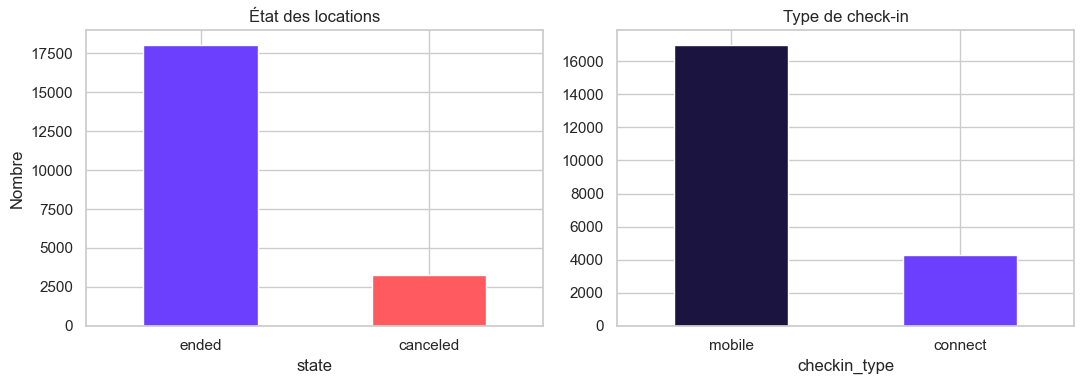

{'ended': 0.847, 'canceled': 0.153}
{'mobile': 0.798, 'connect': 0.202}


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
delay["state"].value_counts().plot.bar(ax=axes[0], color=[PRIMARY, ACCENT], rot=0)
axes[0].set_title("État des locations"); axes[0].set_ylabel("Nombre")
delay["checkin_type"].value_counts().plot.bar(ax=axes[1], color=[INK, PRIMARY], rot=0)
axes[1].set_title("Type de check-in")
plt.tight_layout(); plt.show()

print(delay["state"].value_counts(normalize=True).round(3).to_dict())
print(delay["checkin_type"].value_counts(normalize=True).round(3).to_dict())

### Distribution des retards au checkout

⚠️ **Point de qualité de données** : la variable contient des valeurs extrêmes (de −22 433 à +71 084 min). Pour visualiser, on **borne l'affichage** à ±300 min. Un retard négatif = voiture rendue **en avance**.

min / max bruts : -22433.0 / 71084.0
part en retard (>0) : 57.5% | médiane des retards : 53 min


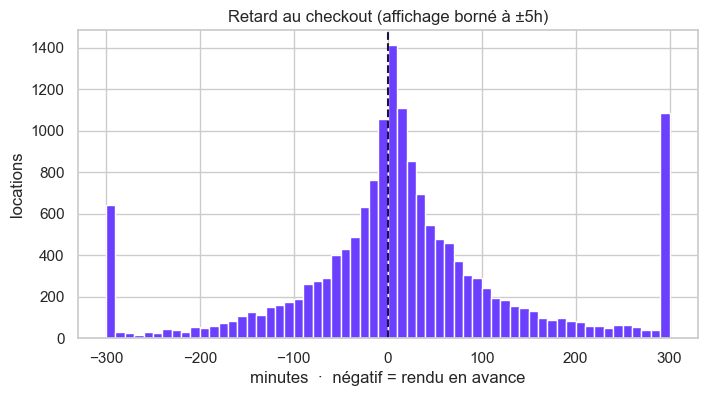

In [9]:
d = delay.loc[delay.state == "ended", "delay_at_checkout_in_minutes"].dropna()
print("min / max bruts :", d.min(), "/", d.max())
print("part en retard (>0) :", f"{(d > 0).mean()*100:.1f}%", "| médiane des retards :", f"{d[d>0].median():.0f} min")
# d > 0).mean() --> quelle part des retards est positive
# d[d>0].median() prend la médiane des seuls retards positifs --> plus robuste, insensible aux outliers 

plt.figure()
# clip(-300, 300) empile aux bornes --> purement cosmétique pour l'histogramme; les statistiques et les simulations utilisent les valeurs réelles
plt.hist(d.clip(-300, 300), bins=60, color=PRIMARY, edgecolor="white")
plt.axvline(0, color=INK, ls="--")
plt.title("Retard au checkout (affichage borné à ±5h)")
plt.xlabel("minutes  ·  négatif = rendu en avance"); plt.ylabel("locations")
plt.show()

### Le sous-ensemble « enchaîné »

Seules les locations ayant une location précédente (`previous_ended_rental_id` rempli) sont concernées par la feature « délai minimum ». On regarde leur poids et l'écart planifié avec la location précédente.

Locations enchaînées : 1841 / 21310 = 8.6%


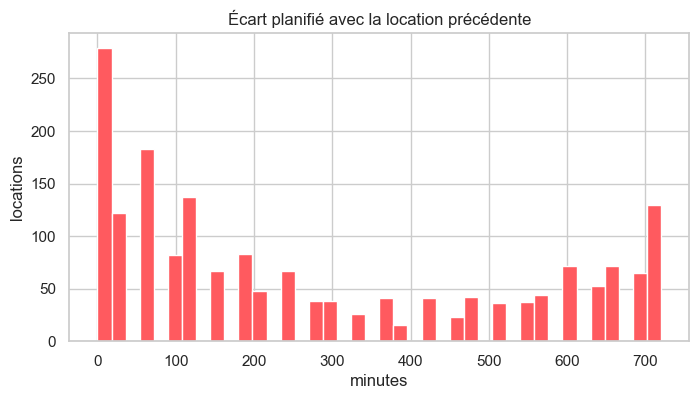

Écart médian : 180 min


In [10]:
# ici on isole les locations « enchaînées » (celles qui suivent une autre location de la même voiture), 
# mesure leur poids dans le total, puis visualise la distribution de l'écart planifié qui les sépare de leur location précédent
chained = delay[delay.previous_ended_rental_id.notna()]
print(f"Locations enchaînées : {len(chained)} / {len(delay)} = {len(chained)/len(delay)*100:.1f}%")

g = chained["time_delta_with_previous_rental_in_minutes"].dropna()
plt.figure()
# Ici, pas de clip. Contrairement à l'histogramme des retards, on trace g directement, sans bornage;
# Parce que cette variable est naturellement bornée --> previous_ended_rental_id n'est rempli que si la location précédente s'est terminée dans les 12h
# L'écart ne peut donc pas dépasser 720 minutes — pas d'outliers à écraser, l'histogramme est lisible tel quel
plt.hist(g, bins=40, color=ACCENT, edgecolor="white")
plt.title("Écart planifié avec la location précédente")
plt.xlabel("minutes"); plt.ylabel("locations")
plt.show()

# g.median() nous dit que la moitié des enchaînements ont moins de 'X' heures de battement;
print("Écart médian :", f"{g.median():.0f} min")

**g.median() (~180 min, soit 3 h) nous dit que la moitié des enchaînements ont moins de 3 h de battement** -->  quand le simulateur teste un seuil de 120 ou 180 minutes, on comprend immédiatement qu'on tape en plein dans le cœur de la distribution — d'où le fait qu'une part non négligeable de locations se retrouve bloquée.

### Croisement type de check-in × état

state         canceled  ended
checkin_type                 
connect          0.185  0.815
mobile           0.145  0.855


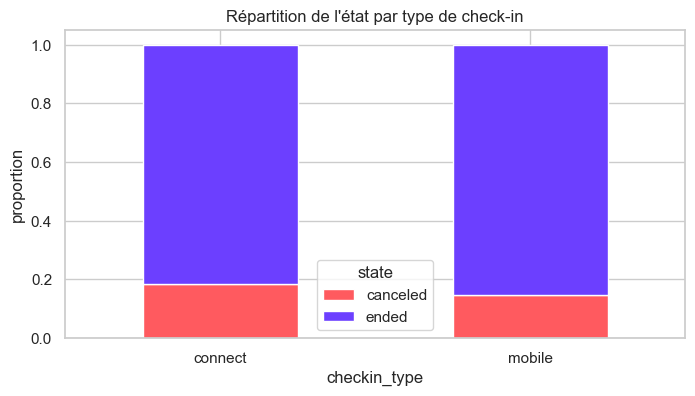

In [11]:
ct = pd.crosstab(delay.checkin_type, delay.state, normalize="index").round(3)
print(ct)
ct.plot.bar(stacked=True, color=[ACCENT, PRIMARY], rot=0)
plt.title("Répartition de l'état par type de check-in"); plt.ylabel("proportion")
plt.legend(title="state"); plt.show()

---
# Partie 2 — Jeu de données du pricing

Une ligne = une voiture. La **cible** à prédire est `rental_price_per_day` (prix de location par jour).

Cette partie est scindée en **2.A — EDA décisionnelle** (pilote le pipeline) et **2.B — EDA d'interprétation** (servira à commenter le modèle).


In [12]:
# index_col=0 : la 1re colonne est un index sans nom (numérotation des voitures)
price = pd.read_csv(DATA / "get_around_pricing_project.csv", index_col=0)
print("Dimensions :", price.shape)
price.head()

Dimensions : (4843, 14)


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


## 🔧 2.A — EDA décisionnelle

> **À quoi sert ce bloc:** chaque section ci-dessous **change une décision** du pipeline de modélisation (nettoyage, encodage, métrique). C'est ce qui nous permet de réfléchir à comment préparer les données. 


### 2.A.1 — Structure et types

> On identifie les colonnes numériques / catégorielles / booléennes → ça conditionne tout le prétraitement.

In [15]:
price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4843 entries, 0 to 4842
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   model_key                  4843 non-null   object
 1   mileage                    4843 non-null   int64 
 2   engine_power               4843 non-null   int64 
 3   fuel                       4843 non-null   object
 4   paint_color                4843 non-null   object
 5   car_type                   4843 non-null   object
 6   private_parking_available  4843 non-null   bool  
 7   has_gps                    4843 non-null   bool  
 8   has_air_conditioning       4843 non-null   bool  
 9   automatic_car              4843 non-null   bool  
 10  has_getaround_connect      4843 non-null   bool  
 11  has_speed_regulator        4843 non-null   bool  
 12  winter_tires               4843 non-null   bool  
 13  rental_price_per_day       4843 non-null   int64 
dtypes: bool(7), i

In [16]:
price.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model_key,4843,28,Citroën,969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,4843.0,NaN,NaN,NaN,140962.799504,60196.740703,-64.0,102913.5,141080.0,175195.5,1000376.0
engine_power,4843.0,NaN,NaN,NaN,128.98823,38.99336,0.0,100.0,120.0,135.0,423.0
fuel,4843,4,diesel,4641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paint_color,4843,10,black,1633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_type,4843,8,estate,1606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
private_parking_available,4843,2,True,2662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_gps,4843,2,True,3839,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_air_conditioning,4843,2,False,3865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
automatic_car,4843,2,False,3881,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.A.2 — Qualité des données

**NETTOYAGE:** Trois anomalies à corriger avant d'entraîner (sinon le modèle apprend du bruit)

In [17]:
print("mileage négatif       :", (price.mileage < 0).sum(), "ligne(s)")
print("mileage aberrant (>1M) :", (price.mileage > 1_000_000).sum(), "ligne(s)")
print("engine_power = 0       :", (price.engine_power == 0).sum(), "ligne(s)")
print("valeurs manquantes     :", int(price.isna().sum().sum()))
display(price[price.mileage < 0])
display(price[price.mileage > 1_000_000])

mileage négatif       : 1 ligne(s)
mileage aberrant (>1M) : 1 ligne(s)
engine_power = 0       : 1 ligne(s)
valeurs manquantes     : 0


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
2938,Renault,-64,230,diesel,black,sedan,True,True,False,True,False,False,True,274


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
3732,Citroën,1000376,90,diesel,black,subcompact,True,False,False,False,False,False,True,37


### 2.A.3 — Distribution de la cible (`rental_price_per_day`)

On vérifie ici l'asymétrie de la distribution : une cible fortement étalée à droite justifierait une transformation (log) et rendrait la RMSE peu représentative. La cellule suivante mesure cette asymétrie plutôt que de la supposer.

In [18]:
# --- Diagnostic d'asymétrie de la cible ---
# Trois indices convergents pour juger si la distribution est "étalée à droite" :
y = price.rental_price_per_day

# 1) moyenne vs médiane : si la moyenne est TIRÉE vers le haut par une traîne
#    de valeurs élevées, elle dépasse nettement la médiane. Si les deux sont
#    proches -> distribution quasi symétrique.
print(f"moyenne = {y.mean():.1f}  |  médiane = {y.median():.1f}")

# 2) skewness (coefficient d'asymétrie) : 0 = symétrique, > 1 = franchement
#    étalé à droite, < -1 = étalé à gauche.
print(f"skewness = {y.skew():.2f}")

# 3) percentiles + poids réel de la queue : combien de voitures peuplent
#    vraiment la partie droite du graphique ?
print("percentiles :", {f"p{p}": round(y.quantile(p/100)) for p in [1, 5, 25, 50, 75, 95, 99]})
print(f"max = {y.max()}  |  voitures > 250 € : {(y > 250).sum()} ({(y > 250).mean()*100:.2f} %)")

moyenne = 121.2  |  médiane = 119.0
skewness = 0.62
percentiles : {'p1': 28, 'p5': 70, 'p25': 104, 'p50': 119, 'p75': 136, 'p95': 182, 'p99': 216}
max = 422  |  voitures > 250 € : 15 (0.31 %)


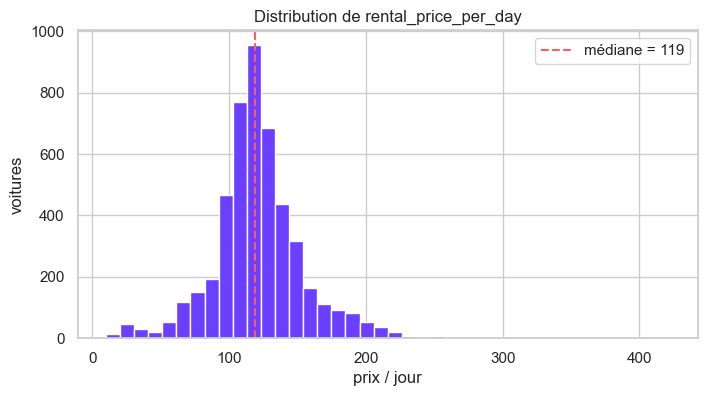

{'count': 4843.0, 'mean': 121.2, 'std': 33.6, 'min': 10.0, '25%': 104.0, '50%': 119.0, '75%': 136.0, 'max': 422.0}


In [19]:
plt.figure()
plt.hist(price.rental_price_per_day, bins=40, color=PRIMARY, edgecolor="white")
plt.axvline(price.rental_price_per_day.median(), color=ACCENT, ls="--",
            label=f"médiane = {price.rental_price_per_day.median():.0f}")
plt.title("Distribution de rental_price_per_day"); plt.xlabel("prix / jour"); plt.ylabel("voitures")
plt.legend(); plt.show()
print(price.rental_price_per_day.describe().round(1).to_dict())

**l'asymétrie est légère**, la longue plage de l'axe vient d'une poignée de valeurs extrêmes — une transformation log n'est donc a priori pas justifiée, ce que le notebook 02 vérifiera empiriquement.

### 2.A.4 — Cardinalité des variables catégorielles

**Décide l'ENCODAGE.** Le nombre de modalités (cardinalité) dicte la stratégie : peu de modalités → one-hot direct ; beaucoup (ex. `model_key`) → one-hot lourd, on envisage de regrouper les modalités rares.

             nb_modalités modalité_dominante  part_dominante_%
model_key              28            Citroën              20.0
fuel                    4             diesel              95.8
paint_color            10              black              33.7
car_type                8             estate              33.2


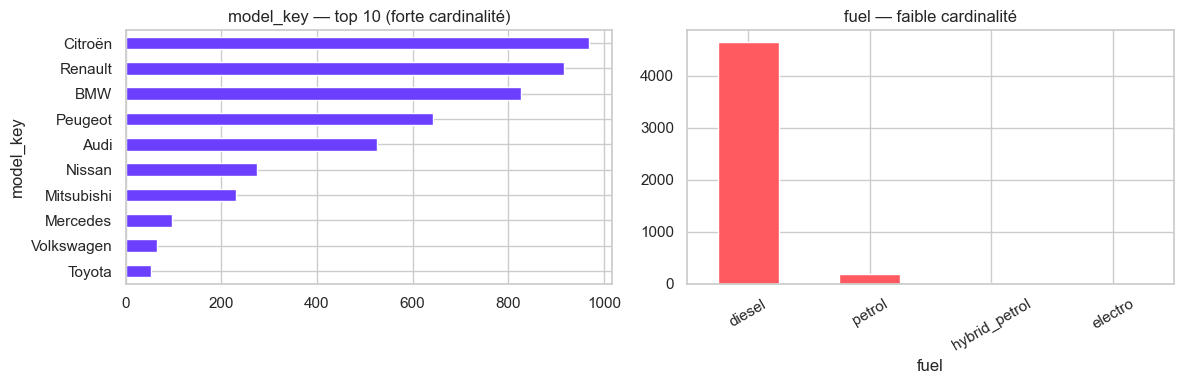

In [20]:
cat_cols = ["model_key", "fuel", "paint_color", "car_type"]
card = pd.DataFrame({
    "nb_modalités": [price[c].nunique() for c in cat_cols],
    "modalité_dominante": [price[c].value_counts().index[0] for c in cat_cols],
    "part_dominante_%": [round(price[c].value_counts(normalize=True).iloc[0]*100, 1) for c in cat_cols],
}, index=cat_cols)
print(card)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
price.model_key.value_counts().head(10).plot.barh(ax=axes[0], color=PRIMARY)
axes[0].set_title("model_key — top 10 (forte cardinalité)"); axes[0].invert_yaxis()
price.fuel.value_counts().plot.bar(ax=axes[1], color=ACCENT, rot=30)
axes[1].set_title("fuel — faible cardinalité")
plt.tight_layout(); plt.show()

> **Bilan 2.A:** nettoyer les 3 anomalies → séparer numériques / catégorielles / booléennes → one-hot des catégorielles (en surveillant `model_key`) → standardiser les numériques si modèle linéaire → métrique RMSE + MAE sur une cible étalée à droite.

## 🔎 2.B — EDA d'interprétation

> **À quoi sert ce bloc :** ces sections **ne changent pas** le pipeline (les booléens sont déjà en 0/1, un modèle à base d'arbres ignore la corrélation linéaire…). Elles constituent ta **grille de lecture** pour commenter les *importances de variables* du modèle après l'entraînement : *« le modèle met X en tête, ce qui est cohérent avec mon EDA »*.


### 2.B.1 — Options booléennes vs prix

Pour chaque équipement : part de voitures équipées, et prix moyen **avec / sans**. Donne une intuition des options qui « valent » cher.

In [21]:
bool_cols = ["private_parking_available","has_gps","has_air_conditioning",
             "automatic_car","has_getaround_connect","has_speed_regulator","winter_tires"]
rows = []
for c in bool_cols:
    rows.append({
        "option": c,
        "% équipées": round(price[c].mean()*100, 1),
        "prix moyen SI": round(price.loc[price[c], "rental_price_per_day"].mean(), 1),
        "prix moyen SINON": round(price.loc[~price[c], "rental_price_per_day"].mean(), 1),
    })
opt = pd.DataFrame(rows)
opt["écart €"] = (opt["prix moyen SI"] - opt["prix moyen SINON"]).round(1)
opt.sort_values("écart €", ascending=False)

,option,% équipées,prix moyen SI,prix moyen SINON,écart €
3,automatic_car,19.9,149.5,114.2,35.3
1,has_gps,79.3,126.6,100.8,25.8
4,has_getaround_connect,46.0,132.8,111.3,21.5
2,has_air_conditioning,20.2,137.6,117.1,20.5
0,private_parking_available,55.0,129.8,110.8,19.0
5,has_speed_regulator,24.1,134.8,116.9,17.9
6,winter_tires,93.2,121.4,118.9,2.5


### 2.B.2 — Variables numériques vs prix + corrélations

**À rappeler** si le modèle classe `engine_power` ou `mileage` haut dans ses importances.

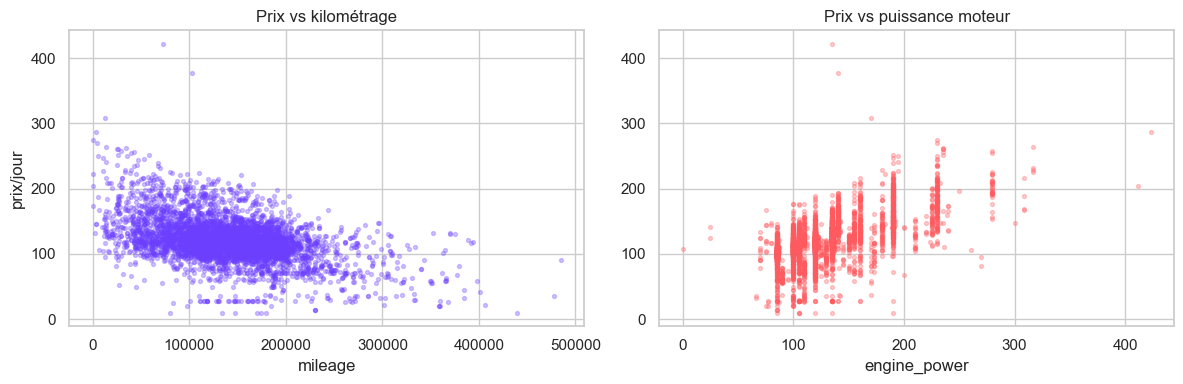

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
m = price[price.mileage < 1_000_000]   # on masque l'aberration pour la lisibilité
axes[0].scatter(m.mileage, m.rental_price_per_day, s=8, alpha=.3, color=PRIMARY)
axes[0].set_title("Prix vs kilométrage"); axes[0].set_xlabel("mileage"); axes[0].set_ylabel("prix/jour")
axes[1].scatter(price.engine_power, price.rental_price_per_day, s=8, alpha=.3, color=ACCENT)
axes[1].set_title("Prix vs puissance moteur"); axes[1].set_xlabel("engine_power")
plt.tight_layout(); plt.show()

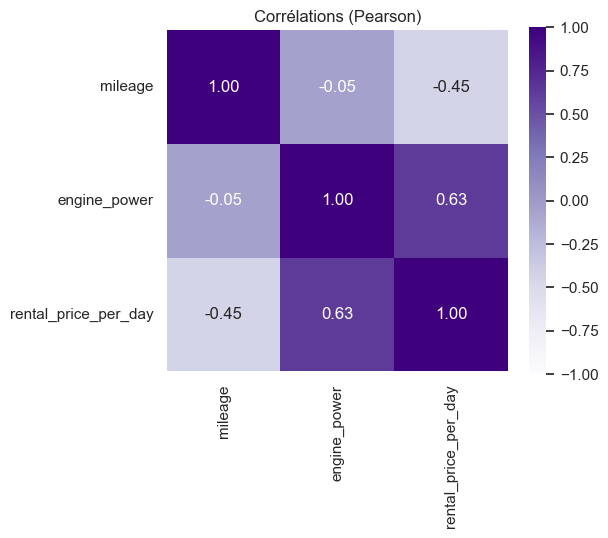

In [23]:
num = price[["mileage","engine_power","rental_price_per_day"]].copy()
num = num[num.mileage < 1_000_000]
plt.figure(figsize=(5.5,4.5))
sns.heatmap(num.corr(), annot=True, cmap="Purples", vmin=-1, vmax=1, fmt=".2f", square=True)
plt.title("Corrélations (Pearson)"); plt.show()

### 2.B.3 — Prix moyen par catégorie

**👉 À rappeler** si le modèle valorise certaines marques / carrosseries / carburants.

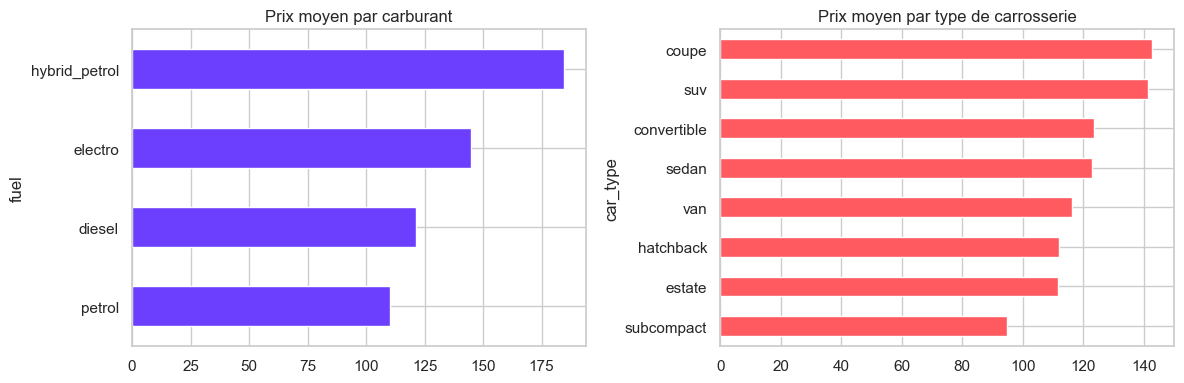

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
price.groupby("fuel").rental_price_per_day.mean().sort_values().plot.barh(ax=axes[0], color=PRIMARY)
axes[0].set_title("Prix moyen par carburant")
price.groupby("car_type").rental_price_per_day.mean().sort_values().plot.barh(ax=axes[1], color=ACCENT)
axes[1].set_title("Prix moyen par type de carrosserie")
plt.tight_layout(); plt.show()

---
## Synthèse — ce qu'il faut retenir

**Partie 1 — délais (pour le dashboard)**
- ~85 % `ended` / ~15 % `canceled` ; ~80 % `mobile` / ~20 % `connect`.
- ~57 % des retours en retard (médiane ~53 min), outliers extrêmes à borner pour l'affichage.
- Seules ~9 % des locations sont **enchaînées** → population concernée par le « délai minimum ».

**Partie 2 — pricing**

| | Section | Rôle |
|---|---|---|
| 🔧 | 2.A.1 Structure | typer les colonnes |
| 🔧 | 2.A.2 Qualité | **nettoyer** mileage<0, >1M, engine_power=0 |
| 🔧 | 2.A.3 Cible | choisir la **métrique** (cible étalée à droite) |
| 🔧 | 2.A.4 Cardinalité | choisir l'**encodage** (one-hot ; surveiller `model_key`) |
| 🔎 | 2.B.1 Booléens | interpréter les options « qui valent cher » |
| 🔎 | 2.B.2 Numériques + corr. | interpréter `engine_power` / `mileage` |
| 🔎 | 2.B.3 Prix par catégorie | interpréter marques / carrosseries / carburants |

➡️ **Prochaine étape (Partie 2 du projet)** : nettoyage (bloc 2.A) → pipeline de prétraitement (encodage + standardisation) → entraînement d'une régression → **suivi des expériences avec MLflow** → interprétation des importances (grille du bloc 2.B).
